# Tutorial: RL Reward Design — A Countdown Case Study

This tutorial uses the **Countdown number game** to explore how reward function
design affects RL training. You will:

1. Define a `ProblemEnv` with a verifiable reward function
2. Compare **binary** vs **partial credit** rewards on the same task
3. Train two models using the cookbook's `rl.train.main()` — one per reward mode
4. Analyze the training curves and rollouts to understand what each model learns

The Countdown task: given 3–4 numbers and a target, combine them with `+`, `-`,
`*`, `/` to reach the target. Each number can be used at most once.

> **Example**: numbers = [3, 7, 2], target = 13 → `3 * 2 + 7 = 13`

In [1]:
import math
import json
import re
import warnings
from collections.abc import Sequence
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import nest_asyncio; nest_asyncio.apply()

warnings.filterwarnings("ignore", message="IProgress not found")

import tinker
from datasets import load_dataset

from tinker_cookbook import checkpoint_utils
from tinker_cookbook.renderers import get_renderer, get_text_content
from tinker_cookbook.rl.problem_env import ProblemEnv, ProblemGroupBuilder
from tinker_cookbook.rl.train import Config, main
from tinker_cookbook.rl.types import EnvGroupBuilder, RLDataset, StepResult
from tinker_cookbook.tokenizer_utils import get_tokenizer

## Step 1 — The reward function

A good RL reward function is **verifiable** (we can check correctness programmatically)
and **informative** (it gives the model useful gradient signal).

We define two grading modes: **binary** (pass/fail) and **partial credit** which gives
intermediate rewards for expressions that use valid numbers but get the wrong result.
The partial score includes a proximity bonus — closer to the target means higher reward.

In [2]:
def evaluate_expression(
    expression: str, available_nums: list[int], target: int
) -> tuple[bool, float]:
    """Grade a countdown expression.

    Returns:
        (is_correct, partial_score) where partial_score is:
        - 0.0 if invalid expression or uses wrong numbers
        - 0.3 + proximity bonus (up to 0.3) if valid but wrong result
        - 1.0 if exactly correct
    """
    try:
        if not re.match(r"^[\d\s\+\-\*/\(\)\.]+$", expression):
            return False, 0.0

        used_nums = [int(n) for n in re.findall(r"\d+", expression)]
        remaining = list(available_nums)
        for n in used_nums:
            if n in remaining:
                remaining.remove(n)
            else:
                return False, 0.0

        result = eval(expression)
        if abs(result - target) < 1e-6:
            return True, 1.0

        # Partial credit: proximity to target
        if target != 0:
            relative_error = abs(result - target) / abs(target)
            proximity = max(0.0, 1.0 - relative_error)
        else:
            proximity = 1.0 if abs(result) < 1e-6 else 0.0
        return False, 0.3 + 0.3 * proximity
    except Exception:
        return False, 0.0


def extract_boxed(response: str) -> str | None:
    """Extract expression from \\boxed{} or last arithmetic line."""
    match = re.search(r"\\boxed\{([^}]+)\}", response)
    if match:
        return match.group(1).strip()
    for line in reversed(response.strip().splitlines()):
        line = line.strip()
        if re.search(r"\d+\s*[\+\-\*/]", line):
            return re.sub(r"^[=:\s]+", "", line).strip()
    return None

### See the difference: binary vs partial credit

Let's grade the same set of responses both ways:

In [3]:
target = 98
nums = [44, 19, 35]

examples = [
    "44 + 19 + 35",   # correct
    "44 + 35",         # valid numbers, result=79 (close)
    "44 + 19",         # valid numbers, result=63 (farther)
    "50 + 48",         # invalid numbers
]

print(f"Target: {target}, Numbers: {nums}\n")
print(f"{'Expression':<20} {'Binary':>8} {'Partial':>8}  {'Eval':>6}")
print("-" * 60)
for expr in examples:
    is_correct, partial_score = evaluate_expression(expr, nums, target)
    binary = 1.0 if is_correct else 0.0
    try:
        val = eval(expr)
    except Exception:
        val = "err"
    print(f"{expr:<20} {binary:>8.1f} {partial_score:>8.2f}  {val!s:>6}")

Target: 98, Numbers: [44, 19, 35]

Expression             Binary  Partial    Eval
------------------------------------------------------------
44 + 19 + 35              1.0     1.00      98
44 + 35                   0.0     0.54      79
44 + 19                   0.0     0.49      63
50 + 48                   0.0     0.00      98


Binary gives 0.0 to everything except the perfect answer. Partial credit gives
**0.54** for "close to target" and **0.49** for "farther off." This variance within
a GRPO group is what creates learning signal — if all completions score 0.0, every
advantage is zero and the group contributes nothing to the gradient.

## Step 2 — Define the CountdownEnv

Subclass `ProblemEnv` and implement four methods. We also override `step()` to
support partial-credit rewards — the base class only does binary scoring.

In [4]:
class CountdownEnv(ProblemEnv):
    """Single-turn env: reach the target using arithmetic on the given numbers."""

    def __init__(self, target, nums, renderer, convo_prefix=None, use_partial=True):
        super().__init__(renderer, convo_prefix)
        self.target = target
        self.nums = nums
        self.use_partial = use_partial

    def get_question(self) -> str:
        nums_str = ", ".join(str(n) for n in self.nums)
        return (
            f"Using the numbers [{nums_str}], create an arithmetic expression "
            f"that equals {self.target}. You can use +, -, *, / and each number "
            r"at most once. Put your final expression in \boxed{}."
        )

    def check_answer(self, sample_str: str) -> bool:
        expr = extract_boxed(sample_str)
        if expr is None:
            return False
        correct, _ = evaluate_expression(expr, self.nums, self.target)
        return correct

    def check_format(self, sample_str: str) -> bool:
        return extract_boxed(sample_str) is not None

    def get_reference_answer(self) -> str:
        return f"target={self.target}, nums={self.nums}"

    async def step(self, action, *, extra=None):
        """Score with partial credit when use_partial=True."""
        if not self.use_partial:
            return await super().step(action, extra=extra)

        # Parse the model's response
        message, parse_success = self.renderer.parse_response(action)
        content = get_text_content(message)
        correct_format = float(parse_success) and float(self.check_format(content))
        correct_answer = float(self.check_answer(content))

        # Partial reward: grade proximity to target
        expr = extract_boxed(content)
        if expr is not None and not correct_answer:
            _, partial_score = evaluate_expression(expr, self.nums, self.target)
        else:
            partial_score = 1.0 if correct_answer else 0.0

        reward_value = partial_score if not correct_answer else 1.0
        total_reward = self.format_coef * (correct_format - 1) + reward_value

        return StepResult(
            reward=total_reward,
            episode_done=True,
            next_observation=tinker.ModelInput.empty(),
            next_stop_condition=self.stop_condition,
            metrics={"format": correct_format, "correct": correct_answer, "partial_reward": partial_score},
        )

print("CountdownEnv defined.")
print(f"Example question: {CountdownEnv(98, [44, 19, 35], renderer=None).get_question()}")

CountdownEnv defined.
Example question: Using the numbers [44, 19, 35], create an arithmetic expression that equals 98. You can use +, -, *, / and each number at most once. Put your final expression in \boxed{}.


## Step 3 — Build the dataset

The training loop expects an `RLDatasetBuilder` — a `chz` dataclass whose `__call__`
returns `(train_dataset, test_dataset)`. Each dataset yields batches of
`ProblemGroupBuilder`s, one per problem.

We load from [Jiayi-Pan/Countdown-Tasks-3to4](https://huggingface.co/datasets/Jiayi-Pan/Countdown-Tasks-3to4)
(490K problems with 3–4 numbers each).

In [5]:
import chz
from tinker_cookbook.renderers import get_renderer
from tinker_cookbook.rl.types import RLDatasetBuilder

class CountdownDataset(RLDataset):
    def __init__(self, data, batch_size, group_size, renderer, use_partial=True):
        self.data = data
        self.batch_size = batch_size
        self.group_size = group_size
        self.renderer = renderer
        self.use_partial = use_partial
        self.convo_prefix = [
            {"role": "user", "content": (
                "Using the numbers [3, 7, 2], create an arithmetic expression "
                "that equals 13. You can use +, -, *, / and each number at most "
                r"once. Put your final expression in \boxed{}."
            )},
            {"role": "assistant", "content": "3 * 2 = 6, 6 + 7 = 13. Yes!\n\\boxed{3 * 2 + 7}"},
        ]

    def get_batch(self, index: int) -> Sequence[EnvGroupBuilder]:
        start = index * self.batch_size
        end = min(start + self.batch_size, len(self.data))
        return [
            ProblemGroupBuilder(
                env_thunk=partial(
                    CountdownEnv, row["target"], row["nums"], self.renderer,
                    convo_prefix=self.convo_prefix, use_partial=self.use_partial,
                ),
                num_envs=self.group_size,
                dataset_name="countdown",
            )
            for row in self.data[start:end]
        ]

    def __len__(self) -> int:
        return math.ceil(len(self.data) / self.batch_size)


@chz.chz
class CountdownDatasetBuilder(RLDatasetBuilder):
    """Builds train/test datasets from the Countdown-Tasks-3to4 HuggingFace dataset."""
    batch_size: int
    model_name_for_tokenizer: str
    renderer_name: str
    group_size: int
    n_train: int = 10000
    n_test: int = 500
    seed: int = 0
    use_partial: bool = True

    async def __call__(self) -> tuple[CountdownDataset, CountdownDataset]:
        tokenizer = get_tokenizer(self.model_name_for_tokenizer)
        renderer = get_renderer(self.renderer_name, tokenizer=tokenizer)

        ds = load_dataset("Jiayi-Pan/Countdown-Tasks-3to4", split="train").shuffle(seed=self.seed)
        train_data = [{"target": r["target"], "nums": r["nums"]} for r in ds.select(range(self.n_train))]
        test_data = [{"target": r["target"], "nums": r["nums"]} for r in ds.select(range(self.n_train, self.n_train + self.n_test))]

        train_dataset = CountdownDataset(train_data, self.batch_size, self.group_size, renderer, self.use_partial)
        # Test always uses binary reward for clean accuracy measurement
        test_dataset = CountdownDataset(test_data, self.batch_size, 1, renderer, use_partial=False)
        return train_dataset, test_dataset

print("CountdownDatasetBuilder defined.")

CountdownDatasetBuilder defined.


## Step 4 — Train with GRPO

Now we wire the env and dataset into the cookbook's training loop via `rl.train.Config`
and `rl.train.main()`. This handles the full GRPO pipeline: rollouts, advantage
computation, datum assembly, and optimizer steps — plus checkpointing, evaluation,
and logging.

We train two models with identical hyperparameters, differing only in reward mode:
- **Partial credit** — graded rewards for "close but wrong" answers
- **Binary** — 1.0 for correct, 0.0 for everything else

In [6]:
import asyncio

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
LOG_DIR = Path.home() / "tinker-experiments" / "countdown_tutorial"

async def resolve_renderer():
    return await checkpoint_utils.resolve_renderer_name_from_checkpoint_or_default_async(
        model_name=MODEL_NAME, explicit_renderer_name=None, load_checkpoint_path=None,
    )

renderer_name = asyncio.run(resolve_renderer())

def make_config(use_partial: bool, n_steps: int = 3) -> Config:
    """Build a training Config for the countdown task."""
    label = "partial" if use_partial else "binary"
    return Config(
        learning_rate=1e-4,
        dataset_builder=CountdownDatasetBuilder(
            batch_size=16,
            model_name_for_tokenizer=MODEL_NAME,
            renderer_name=renderer_name,
            group_size=8,
            n_train=800,
            n_test=100,
            use_partial=use_partial,
        ),
        model_name=MODEL_NAME,
        renderer_name=renderer_name,
        max_tokens=1024,
        log_path=str(LOG_DIR / label),
        eval_every=5,
        save_every=5,
        max_steps=n_steps,
        num_groups_to_log=2,
    )

partial_config = make_config(use_partial=True, n_steps=3)
binary_config = make_config(use_partial=False, n_steps=3)

print(f"partial: log_path={partial_config.log_path}")
print(f"binary:  log_path={binary_config.log_path}")

partial: log_path=/home/yujia/tinker-experiments/countdown_tutorial/partial
binary:  log_path=/home/yujia/tinker-experiments/countdown_tutorial/binary


In [7]:
import shutil

# Train with partial credit rewards
shutil.rmtree(partial_config.log_path, ignore_errors=True)
print("=== Training with PARTIAL CREDIT rewards ===")
await main(partial_config)

=== Training with PARTIAL CREDIT rewards ===


root:654 [INFO] Command line invocation: /home/yujia/.local/lib/python3.12/site-packages/ipykernel_launcher.py -f /tmp/tmp7quxzt74.json --HistoryManager.hist_file=:memory:


tinker_cookbook.utils.ml_log:592 [INFO] Logging to: /home/yujia/tinker-experiments/countdown_tutorial/partial


tinker_cookbook.checkpoint_utils:392 [INFO] No checkpoints found at /home/yujia/tinker-experiments/countdown_tutorial/partial/checkpoints.jsonl


tinker_cookbook.checkpoint_utils:423 [INFO] No checkpoints found with key state_path in /home/yujia/tinker-experiments/countdown_tutorial/partial


...

tinker_cookbook.rl.train:261 [INFO] 
====== Trajectory Group ======
****** trajectory idx=0, reward=1 ******
Per-step metrics:
  Step 0:
    format: 1.0
    correct: 1.0
    partial_reward: 1.0
---- datum ----
<|im_start|>user
Using the numbers [3, 7, 2], create an arithmetic expression that equals 13. You can use +, -, *, / and each number at most once. Put your final expression in \boxed{}.<|im_end|>
<|im_start|>assistant
3 * 2 = 6, 6 + 7 = 13. Yes!
\boxed{3 * 2 + 7}<|im_end|>
<|im_start|>user
Using the numbers [41, 7, 42, 81], create an arithmetic expression that equals 89. You can use +, -, *, / and each number at most once. Put your final expression in \boxed{}.<|im_end|>
<|im_start|>assistant
We are given the numbers: [41, 7, 42, 81]  
We need to create an arithmetic expression using **each number at most once** and using only +, −, ×, ÷ to get a result of **89**.

Let’s explore combinations.

First, note that:

- 81 is very close to 89 → 89 − 81 = 8
- So can we make 8 from the r

tinker_cookbook.utils.ml_log:192 [INFO] Wrote metrics to /home/yujia/tinker-experiments/countdown_tutorial/partial/metrics.jsonl


tinker_cookbook.utils.ml_log:265 [INFO] 
                                 Step 2                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                                                  ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/ac_tokens_per_turn                              │ 563.359375 │
│ env/all/by_group/frac_all_bad                           │ 0.187500   │
│ env/all/by_group/frac_all_good                          │ 0.437500   │
│ env/all/by_group/frac_mixed                             │ 0.375000   │
│ env/all/correct                                         │ 0.492188   │
│ env/all/format                                          │ 0.710938   │
│ env/all/ob_tokens_per_turn                              │ 143.562500 │
│ env/all/partial_reward                                  │ 0.492188   │
│ env/all/reward/total                                    │ 0.463281   │
│ env/all/

tinker_cookbook.checkpoint_utils:461 [INFO] Saved checkpoints: {'state_path': 'tinker://0f6474b9-b7ca-5c6a-91b9-8ea96fd0fdd8:train:0/weights/final', 'sampler_path': 'tinker://0f6474b9-b7ca-5c6a-91b9-8ea96fd0fdd8:train:0/sampler_weights/final'}


tinker_cookbook.rl.train:2014 [INFO] Training completed successfully


In [8]:
# Train with binary rewards (run this cell after the partial training cell completes)
shutil.rmtree(binary_config.log_path, ignore_errors=True)
print("=== Training with BINARY rewards ===")
await main(binary_config)

=== Training with BINARY rewards ===


tinker_cookbook.utils.ml_log:265 [INFO] 
Configuration:
  learning_rate: 0.0001
  dataset_builder: {'batch_size': 16, 'model_name_for_tokenizer': 'Qwen/Qwen3-4B-Instruct-2507', 'renderer_name': 
'qwen3_instruct', 'group_size': 8, 'n_train': 800, 'n_test': 100, 'seed': 0, 'use_partial': False}
  model_name: 'Qwen/Qwen3-4B-Instruct-2507'
  max_tokens: 1024
  log_path: '/home/yujia/tinker-experiments/countdown_tutorial/binary'
  eval_every: 5
  save_every: 5
  evaluator_builders: []
  load_checkpoint_path: None
  renderer_name: 'qwen3_instruct'
  wandb_project: None
  wandb_name: None
  kl_penalty_coef: 0.0
  kl_discount_factor: 0.0
  kl_reference_config: None
  loss_fn: 'importance_sampling'
  loss_fn_config: None
  num_substeps: 1
  lora_rank: 32
  temperature: 1.0
  compute_post_kl: False
  remove_constant_reward_groups: False
  rollout_error_tolerance: False
  enable_trace: False
  span_chart_every: 0
  async_config: None
  stream_minibatch_config: None
  base_url: None
  ttl_seconds:

root:654 [INFO] Command line invocation: /home/yujia/.local/lib/python3.12/site-packages/ipykernel_launcher.py -f /tmp/tmp7quxzt74.json --HistoryManager.hist_file=:memory:


tinker_cookbook.utils.ml_log:592 [INFO] Logging to: /home/yujia/tinker-experiments/countdown_tutorial/binary


tinker_cookbook.checkpoint_utils:392 [INFO] No checkpoints found at /home/yujia/tinker-experiments/countdown_tutorial/binary/checkpoints.jsonl


...

tinker_cookbook.rl.train:261 [INFO] 
====== Trajectory Group ======
****** trajectory idx=0, reward=1 ******
Per-step metrics:
  Step 0:
    format: 1.0
    correct: 1.0
---- datum ----
<|im_start|>user
Using the numbers [3, 7, 2], create an arithmetic expression that equals 13. You can use +, -, *, / and each number at most once. Put your final expression in \boxed{}.<|im_end|>
<|im_start|>assistant
3 * 2 = 6, 6 + 7 = 13. Yes!
\boxed{3 * 2 + 7}<|im_end|>
<|im_start|>user
Using the numbers [41, 7, 42, 81], create an arithmetic expression that equals 89. You can use +, -, *, / and each number at most once. Put your final expression in \boxed{}.<|im_end|>
<|im_start|>assistant
We are given the numbers: **41, 7, 42, 81**  
We need to create an arithmetic expression using **each number at most once** and using only **+**, **−**, **×**, **÷** to get **89**.

Let’s explore possible combinations.

First, observe that 81 is close to 89.  
89 − 81 = 8.  
So we need to form **8** from the remain

tinker_cookbook.utils.ml_log:192 [INFO] Wrote metrics to /home/yujia/tinker-experiments/countdown_tutorial/binary/metrics.jsonl


tinker_cookbook.utils.ml_log:265 [INFO] 
                                 Step 2                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                                                  ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/ac_tokens_per_turn                              │ 589.023438 │
│ env/all/by_group/frac_all_bad                           │ 0.187500   │
│ env/all/by_group/frac_all_good                          │ 0.437500   │
│ env/all/by_group/frac_mixed                             │ 0.375000   │
│ env/all/correct                                         │ 0.507812   │
│ env/all/format                                          │ 0.640625   │
│ env/all/ob_tokens_per_turn                              │ 143.562500 │
│ env/all/reward/total                                    │ 0.471875   │
│ env/all/total_ac_tokens                                 │ 75395      │
│ env/all/

tinker_cookbook.checkpoint_utils:461 [INFO] Saved checkpoints: {'state_path': 'tinker://751bbce2-8fdd-53d4-aeef-927a2e2f0c86:train:0/weights/final', 'sampler_path': 'tinker://751bbce2-8fdd-53d4-aeef-927a2e2f0c86:train:0/sampler_weights/final'}


tinker_cookbook.rl.train:2014 [INFO] Training completed successfully


## Step 5 — Compare training dynamics

Both runs wrote `metrics.jsonl` to their log directories. Let's load them and
compare accuracy, useful groups, and response length side by side.

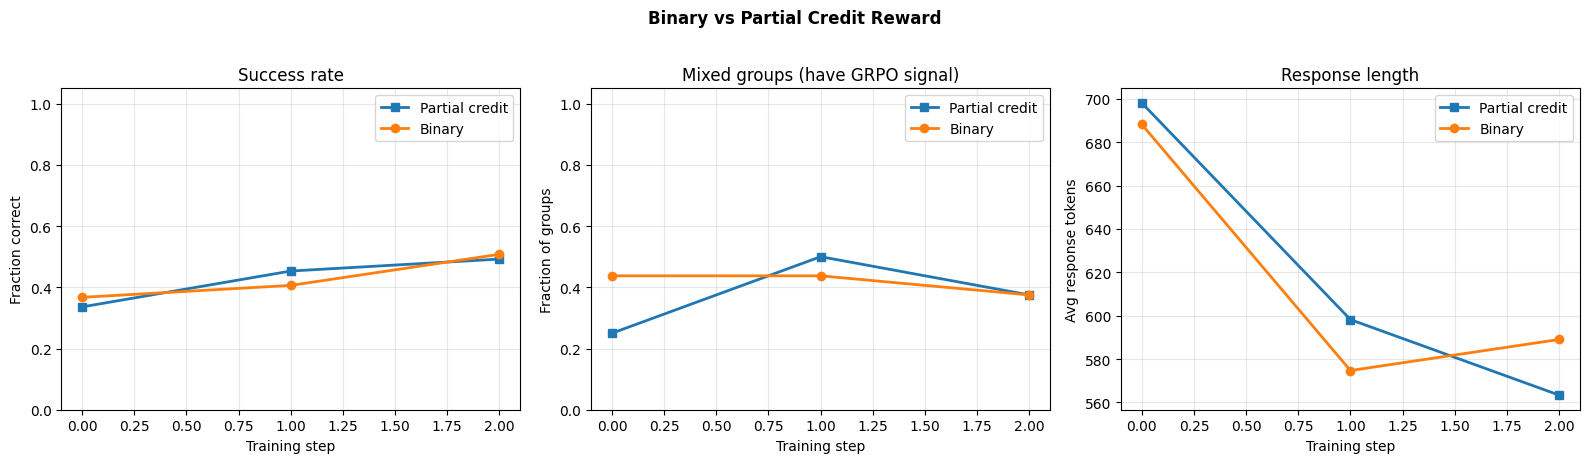

In [9]:
def load_metrics(log_path: str) -> list[dict]:
    """Load metrics.jsonl from a training run."""
    metrics_path = Path(log_path) / "metrics.jsonl"
    with open(metrics_path) as f:
        return [json.loads(line) for line in f]

partial_metrics = load_metrics(partial_config.log_path)
binary_metrics = load_metrics(binary_config.log_path)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

for metrics, label, marker in [(partial_metrics, "Partial credit", "s-"), (binary_metrics, "Binary", "o-")]:
    steps = [m["progress/batch"] for m in metrics]
    ax1.plot(steps, [m["env/all/correct"] for m in metrics], marker, label=label, linewidth=2)
    ax2.plot(steps, [1 - m["env/all/by_group/frac_all_bad"] - m["env/all/by_group/frac_all_good"] for m in metrics], marker, label=label, linewidth=2)
    ax3.plot(steps, [m["env/all/ac_tokens_per_turn"] for m in metrics], marker, label=label, linewidth=2)

ax1.set_xlabel("Training step"); ax1.set_ylabel("Fraction correct")
ax1.set_title("Success rate"); ax1.set_ylim(0, 1.05); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Training step"); ax2.set_ylabel("Fraction of groups")
ax2.set_title("Mixed groups (have GRPO signal)"); ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(True, alpha=0.3)

ax3.set_xlabel("Training step"); ax3.set_ylabel("Avg response tokens")
ax3.set_title("Response length"); ax3.legend(); ax3.grid(True, alpha=0.3)

fig.suptitle("Binary vs Partial Credit Reward", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## Step 6 — Analyze rollouts

The training loop writes rollout transcripts to `iteration_*/train_rollout_summaries.jsonl`.
Let's look at actual model responses to understand *why* partial credit helps.

In [10]:
def load_rollout_summaries(log_path: str, iteration: int = 0) -> list[dict]:
    """Load per-trajectory rollout summaries from a training run."""
    path = Path(log_path) / f"iteration_{iteration:06d}" / "train_rollout_summaries.jsonl"
    if not path.exists():
        print(f"No rollout summaries at {path}")
        return []
    with open(path) as f:
        return [json.loads(line) for line in f]

def analyze_rollouts(log_path: str, label: str, iteration: int = 0):
    """Print a summary of rollout statistics."""
    records = load_rollout_summaries(log_path, iteration)
    if not records:
        return

    total = len(records)
    correct = sum(1 for r in records if r["steps"][0]["metrics"]["correct"] > 0)
    format_ok = sum(1 for r in records if r["steps"][0]["metrics"]["format"] > 0)
    ac_lens = [r["steps"][0]["ac_len"] for r in records]
    truncated = sum(1 for l in ac_lens if l >= 1020)

    print(f"=== {label} (iteration {iteration}) ===")
    print(f"  Trajectories: {total}")
    print(f"  Correct: {correct}/{total} ({correct/total:.0%})")
    print(f"  Format OK: {format_ok}/{total} ({format_ok/total:.0%})")
    print(f"  Avg tokens: {sum(ac_lens)/len(ac_lens):.0f}")
    print(f"  Truncated (>=1020 tokens): {truncated}/{total}")

    # Group-level analysis
    groups = {}
    for r in records:
        gid = r["group_idx"]
        if gid not in groups:
            groups[gid] = []
        groups[gid].append(r["steps"][0]["metrics"]["correct"] > 0)

    all_bad = sum(1 for g in groups.values() if not any(g))
    all_good = sum(1 for g in groups.values() if all(g))
    mixed = len(groups) - all_bad - all_good
    print(f"  Groups: {len(groups)} total, {all_bad} all-bad, {mixed} mixed, {all_good} all-good")
    print()

# Compare step 0 rollouts for both modes
analyze_rollouts(partial_config.log_path, "Partial credit")
analyze_rollouts(binary_config.log_path, "Binary")

=== Partial credit (iteration 0) ===
  Trajectories: 128
  Correct: 43/128 (34%)
  Format OK: 66/128 (52%)
  Avg tokens: 698
  Truncated (>=1020 tokens): 62/128
  Groups: 16 total, 9 all-bad, 3 mixed, 4 all-good

=== Binary (iteration 0) ===
  Trajectories: 128
  Correct: 47/128 (37%)
  Format OK: 72/128 (56%)
  Avg tokens: 688
  Truncated (>=1020 tokens): 56/128
  Groups: 16 total, 7 all-bad, 4 mixed, 5 all-good



## What we learned

- **Partial credit** creates reward variance within groups that would otherwise be
  "all-bad" (every completion wrong, zero advantage, zero gradient). This is the
  key mechanism: GRPO needs *within-group* differences to learn.

- **Token budget matters**: if the model runs out of tokens before writing `\boxed{}`,
  it gets zero reward even if the reasoning was correct. A generous budget lets the
  model explore; GRPO then teaches it to be concise (response length drops naturally).

- **Look at your rollouts**: metrics tell you *what* is happening, rollouts tell
  you *why*. In our experiments with longer training (40 steps, 2048 tokens), 100%
  of remaining failures at 85% accuracy were token truncations — not wrong answers.

- **The cookbook handles the GRPO loop** — you only need to define the `ProblemEnv`
  (task-specific reward) and the `RLDatasetBuilder` (data loading). Everything
  else (`Config` + `main()`) is reusable.

## Other settings to try

The recipe at `tinker_cookbook/recipes/countdown_rl/` supports several configurations.
Here is what we found from a sweep of 8 experiments:

| Change | Effect |
|---|---|
| `reward_mode=binary` | −4% test accuracy (fewer useful groups) |
| `max_tokens=2048` | +9% test accuracy (fewer truncations) |
| `max_tokens=512` | −8% test accuracy (many truncations) |
| `group_size=32` | Eliminates all-bad groups, same peak accuracy |
| `kl_penalty_coef=0.02` | −6% (too conservative for this task) |
| `include_fewshot=False` | −4% (model struggles with format cold-start) |
| `temperature=0.7` | −1.5% (less exploration hurts GRPO) |

Run the full recipe with:
```bash
python -m tinker_cookbook.recipes.countdown_rl.train \
    max_tokens=2048 n_train=3200 n_test=200 max_steps=40
```